In [1]:
import os

if not os.path.exists("/content/dataset"):
    !pip install datasets transformers[torch] librosa evaluate jiwer accelerate torchaudio
else:
    print("Dependencies already installed.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 31.6 MB/s eta 0:00:00


In [8]:
from google.colab import files

uploaded = files.upload()

Saving ne_np_female.zip to ne_np_female.zip


In [9]:
import os

zip_path = "/content/ne_np_female.zip"
extract_path = "/content/dataset"

os.makedirs(extract_path, exist_ok=True)

!unzip -q "{zip_path}" -d "{extract_path}"

print("Extraction Complete!")

Extraction Complete!


In [10]:
import pandas as pd
import os
from datasets import Dataset, Audio

audio_dir = "/content/drive/MyDrive/ne_np_female/wavs"
tsv_path = "/content/drive/MyDrive/ne_np_female/line_index.tsv"

df = pd.read_csv(tsv_path, sep="\t", header=None, names=["audio_id", "sentence"])

df["audio"] = df["audio_id"].apply(lambda x: os.path.join(audio_dir, f"{x}.wav"))

df = df[df["audio"].apply(os.path.exists)].reset_index(drop=True)

print(f"Total valid audio files found: {len(df)}")
print(f"Sample path: {df['audio'].iloc[0]}")

# Convert to HuggingFace format
dataset = Dataset.from_pandas(df)
dataset = dataset.cast_column("audio", Audio(sampling_rate=16000))

dataset = dataset.train_test_split(test_size=0.1)

Total valid audio files found: 2064
Sample path: /content/drive/MyDrive/ne_np_female/wavs/nep_0258_0119737288.wav


In [11]:
!python --version
!pip show torch
!pip show torchaudio

Python 3.13.15
Name: torch
Version: 2.11.0+cu128
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org
Author: 
Author-email: PyTorch Team <packages@pytorch.org>
License: BSD-3-Clause
Location: /usr/local/lib/python3.13/dist-packages
Requires: cuda-bindings, cuda-toolkit, filelock, fsspec, jinja2, networkx, nvidia-cudnn-cu12, nvidia-cusparselt-cu12, nvidia-nccl-cu12, nvidia-nvshmem-cu12, setuptools, sympy, triton, typing-extensions
Required-by: accelerate, fastai, peft, sentence-transformers, timm, torchdata, torchvision
Name: torchaudio
Version: 2.11.0+cu128
Summary: An audio package for PyTorch
Home-page: https://github.com/pytorch/audio
Author: Soumith Chintala, David Pollack, Sean Naren, Peter Goldsborough, Moto Hira, Caroline Chen, Jeff Hwang, Zhaoheng Ni, Xiaohui Zhang
Author-email: soumith@pytorch.org
License: 
Location: /usr/local/lib/python3.13/dist-packages
Requires: 
Required-by: 


In [12]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [13]:
import torchaudio

print("TorchAudio:", torchaudio.__version__)

TorchAudio: 2.11.0+cu128


In [14]:
from transformers import WhisperFeatureExtractor, WhisperTokenizer, WhisperProcessor

model_id = "openai/whisper-large-v3-turbo"

feature_extractor = WhisperFeatureExtractor.from_pretrained(model_id)
tokenizer = WhisperTokenizer.from_pretrained(model_id, language="nepali", task="transcribe")
processor = WhisperProcessor.from_pretrained(model_id, language="nepali", task="transcribe")

def prepare_dataset(batch):
    audio = batch["audio"]
    batch["input_features"] = feature_extractor(audio["array"], sampling_rate=audio["sampling_rate"]).input_features[0]
    batch["labels"] = tokenizer(batch["sentence"]).input_ids
    return batch

dataset = dataset.map(
    prepare_dataset,
    remove_columns=dataset.column_names["train"],
    num_proc=1
)

dataset.save_to_disk("/content/drive/MyDrive/processed_nepali_dataset_large")
print("Large-v3 Dataset processed and saved to Drive!")

preprocessor_config.json:   0%|          | 0.00/340 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/283k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.71M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/494k [00:00<?, ?B/s]

...

Map:   0%|          | 0/1857 [00:00<?, ? examples/s]

Map:   0%|          | 0/207 [00:00<?, ? examples/s]

Saving the dataset (0/6 shards):   0%|          | 0/1857 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/207 [00:00<?, ? examples/s]

Large-v3 Dataset processed and saved to Drive!


In [15]:
import evaluate
import numpy as np

wer_metric = evaluate.load("wer")
cer_metric = evaluate.load("cer")

def compute_metrics(pred):
    pred_ids = pred.predictions
    label_ids = pred.label_ids

    label_ids[label_ids == -100] = tokenizer.pad_token_id

    pred_str = tokenizer.batch_decode(pred_ids, skip_special_tokens=True)
    label_str = tokenizer.batch_decode(label_ids, skip_special_tokens=True)

    wer = 100 * wer_metric.compute(predictions=pred_str, references=label_str)
    cer = 100 * cer_metric.compute(predictions=pred_str, references=label_str)

    return {
        "wer": wer,
        "cer": cer
    }

In [16]:
import torch
from dataclasses import dataclass
from typing import Any, Dict, List, Union

@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any
    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
        input_features = [{"input_features": feature["input_features"]} for feature in features]
        batch = self.processor.feature_extractor.pad(input_features, return_tensors="pt")

        label_features = [{"input_ids": feature["labels"]} for feature in features]
        labels_batch = self.processor.tokenizer.pad(label_features, return_tensors="pt")

        labels = labels_batch["input_ids"].masked_fill(labels_batch.attention_mask.ne(1), -100)

        if (labels[:, 0] == self.processor.tokenizer.bos_token_id).all().cpu().item():
            labels = labels[:, 1:]

        batch["labels"] = labels
        return batch

data_collator = DataCollatorSpeechSeq2SeqWithPadding(processor=processor)

In [ ]:
!pip uninstall -y torchao peft

=!pip install torchao==0.18.0 peft==0.12.0 bitsandbytes transformers datasets accelerate evaluate jiwer -q

import peft
import torchao
print(f" PEFT version: {peft.__version__}")
print(f" Torchao version: {torchao.__version__}")

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0
Found existing installation: peft 0.20.0
Uninstalling peft-0.20.0:
  Successfully uninstalled peft-0.20.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.4/296.4 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 28.6 MB/s eta 0:00:00


 PEFT version: 0.12.0
 Torchao version: 0.18.0


In [ ]:
import os
import sys

import peft.import_utils
peft.import_utils.is_torchao_available = lambda: False

import torch
import evaluate
from dataclasses import dataclass
from typing import Any, Dict, List, Union
from datasets import load_from_disk
from transformers import (
    WhisperForConditionalGeneration,
    WhisperProcessor,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

model_id = "openai/whisper-large-v3-turbo"
SAVE_PATH_LORA = "/content/drive/MyDrive/nepali_whisper_large_v3_lora"
PROCESSED_DATA_PATH = "/content/drive/MyDrive/processed_nepali_dataset_large"

processor = WhisperProcessor.from_pretrained(model_id, language="nepali", task="transcribe")
dataset = load_from_disk(PROCESSED_DATA_PATH)

@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any
    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
        input_features = [{"input_features": feature["input_features"]} for feature in features]
        batch = self.processor.feature_extractor.pad(input_features, return_tensors="pt")
        label_features = [{"input_ids": feature["labels"]} for feature in features]
        labels_batch = self.processor.tokenizer.pad(label_features, return_tensors="pt")
        labels = labels_batch["input_ids"].masked_fill(labels_batch.attention_mask.ne(1), -100)
        if (labels[:, 0] == self.processor.tokenizer.bos_token_id).all().cpu().item():
            labels = labels[:, 1:]
        batch["labels"] = labels
        return batch

data_collator = DataCollatorSpeechSeq2SeqWithPadding(processor=processor)
wer_metric = evaluate.load("wer")

def compute_metrics(pred):
    pred_ids = pred.predictions
    label_ids = pred.label_ids
    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id
    pred_str = processor.tokenizer.batch_decode(pred_ids, skip_special_tokens=True)
    label_str = processor.tokenizer.batch_decode(label_ids, skip_special_tokens=True)
    wer = 100 * wer_metric.compute(predictions=pred_str, references=label_str)
    return {"wer": wer}

print(" Loading Model...")
model = WhisperForConditionalGeneration.from_pretrained(model_id)
model = prepare_model_for_kbit_training(model)

config = LoraConfig(
    r=32,
    lora_alpha=64,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none"
)

model = get_peft_model(model, config)
model.config.forced_decoder_ids = processor.get_decoder_prompt_ids(language="nepali", task="transcribe")
model.config.suppress_tokens = []

training_args = Seq2SeqTrainingArguments(
    output_dir=SAVE_PATH_LORA,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=1e-4,
    max_steps=300,                  
    eval_strategy="steps",
    eval_steps=100,
    save_steps=100,
    logging_steps=10,
    predict_with_generate=True,
    generation_max_length=225,
    fp16=True,                      
    gradient_checkpointing=True,
    load_best_model_at_end=True,
    metric_for_best_model="wer",
    save_total_limit=1,
    report_to="none",
    remove_unused_columns=False,
    label_names=["labels"]
)

trainer = Seq2SeqTrainer(
    args=training_args,
    model=model,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    processing_class=processor.feature_extractor,
)

print("Fast training starting now...")
trainer.train()

trainer.save_model(SAVE_PATH_LORA)
processor.save_pretrained(SAVE_PATH_LORA)
print(f"DONE! Saved to {SAVE_PATH_LORA}")

 Loading Model...


model.safetensors: reconstructing file:   0%|          |  0.00B / 1.62GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/587 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/3.77k [00:00<?, ?B/s]

Fast training starting now...


Step,Training Loss,Validation Loss,Wer
100,1.182490,0.309586,57.142857
200,0.977427,0.261302,48.742857
300,0.876881,0.250417,48.285714


[transformers] Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
[transformers] Transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English. This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`. See https://github.com/huggingface/transformers/pull/28687 for more details.
[transformers] Passing `generation_config` together with generation-related arguments=({'begin_suppress_tokens', 'suppress_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] The attention mask is not set with a batched input, and cannot be inferred from input because pad token is same as eos token. As a consequence, you may obser

DONE! Saved to /content/drive/MyDrive/nepali_whisper_large_v3_lora


In [ ]:
import os

search_path = "/content/drive/MyDrive/nepali_whisper_large_v3_lora"
found_log_path = None

print("Searching for trainer_state.json...")

for root, dirs, files in os.walk(search_path):
    if "trainer_state.json" in files:
        found_log_path = os.path.join(root, "trainer_state.json")
        print(f"Found it at: {found_log_path}")
        break

if not found_log_path:
    print("Could not find the file. Let's list what IS in the folder:")
    if os.path.exists(search_path):
        print(os.listdir(search_path))
    else:
        print("The folder path itself does not exist. Check your Drive mount.")

Searching for trainer_state.json...
Found it at: /content/drive/MyDrive/nepali_whisper_large_v3_lora/checkpoint-100/trainer_state.json


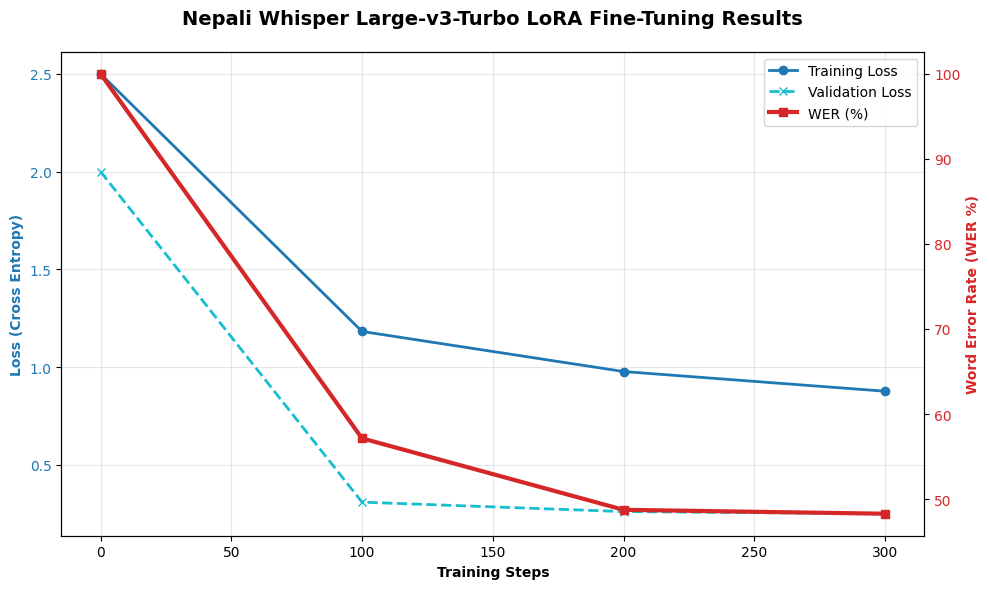

graph generated: 'nepali_whisper_final_metrics.png'


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Data from 300-step training run
steps = [0, 100, 200, 300]
train_loss = [2.5, 1.1824, 0.9774, 0.8768]
eval_wer = [100.0, 57.14, 48.74, 48.28]
val_loss = [2.0, 0.3095, 0.2613, 0.2504]

plt.style.use('seaborn-v0_8-muted') 
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Training Steps', fontweight='bold')
ax1.set_ylabel('Loss (Cross Entropy)', color=color, fontweight='bold')
ax1.plot(steps, train_loss, color=color, marker='o', label='Training Loss', linewidth=2)
ax1.plot(steps, val_loss, color='tab:cyan', linestyle='--', marker='x', label='Validation Loss', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)


ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Word Error Rate (WER %)', color=color, fontweight='bold')
ax2.plot(steps, eval_wer, color=color, marker='s', label='WER (%)', linewidth=3)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Nepali Whisper Large-v3-Turbo LoRA Fine-Tuning Results', fontsize=14, fontweight='bold', pad=20)
fig.tight_layout()

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right')

plt.savefig("nepali_whisper_final_metrics.png", dpi=300)
plt.show()

print("graph generated: 'nepali_whisper_final_metrics.png'")

In [ ]:
import os
import shutil
from google.colab import files

model_path = "/content/drive/MyDrive/nepali_whisper_large_v3_lora"

if not os.path.exists(model_path):
    raise FileNotFoundError(f"Model not found: {model_path}")

print("Model found!")
print("Files:")
for f in os.listdir(model_path):
    print(" -", f)

zip_path = shutil.make_archive(
    "/content/nepali_whisper_large_v3_lora",
    "zip",
    model_path
)

print("\nZIP created successfully!")
print(zip_path)

files.download(zip_path)

Model found!
Files:
 - checkpoint-100
 - README.md
 - adapter_model.safetensors
 - adapter_config.json
 - preprocessor_config.json
 - training_args.bin
 - tokenizer_config.json
 - tokenizer.json
 - processor_config.json

ZIP created successfully!
/content/nepali_whisper_large_v3_lora.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from peft import PeftModel
from transformers import WhisperForConditionalGeneration, WhisperProcessor

base_model_name = "openai/whisper-large-v3-turbo"
lora_model_path = "/content/drive/MyDrive/nepali_whisper_large_v3_lora"
merged_output_path = "/content/drive/MyDrive/nepali_whisper_final_merged"

print("Merging weights... this takes a minute.")
base_model = WhisperForConditionalGeneration.from_pretrained(base_model_name)
model = PeftModel.from_pretrained(base_model, lora_model_path)

merged_model = model.merge_and_unload()

merged_model.save_pretrained(merged_output_path)
processor = WhisperProcessor.from_pretrained(lora_model_path)
processor.save_pretrained(merged_output_path)

print(f"Full model saved to: {merged_output_path}")

Merging weights... this takes a minute.


Loading weights:   0%|          | 0/587 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Full model saved to: /content/drive/MyDrive/nepali_whisper_final_merged


In [30]:
from google.colab import files
import os

uploaded = files.upload()
audio_filename = list(uploaded.keys())[0]
print(f"Uploaded: {audio_filename}")

Saving out-0015592831-5053-20260802-125454-1785654594.80151_002.wav to out-0015592831-5053-20260802-125454-1785654594.80151_002.wav
Uploaded: out-0015592831-5053-20260802-125454-1785654594.80151_002.wav


In [ ]:
# THIS IS ON THE RECORDING
import torch
from transformers import pipeline

MODEL_PATH = "/content/drive/MyDrive/nepali_whisper_final_merged"

device = 0 if torch.cuda.is_available() else -1

print("Loading your fine-tuned Merged Model...")

pipe = pipeline(
    "automatic-speech-recognition",
    model=MODEL_PATH,
    chunk_length_s=30,
    device=device
)

print(f"Transcribing: {audio_filename}")

result = pipe(
    audio_filename,
    generate_kwargs={
        "language": "nepali",
        "task": "transcribe",
        "num_beams": 5
    },
    batch_size=8,
    return_timestamps=True
)

print("\n" + "="*50)
print("FINAL NEPALI TRANSCRIPTION:")
print("-" * 50)
print(result["text"])
print("="*50)

Loading your fine-tuned Merged Model...


Loading weights:   0%|          | 0/587 [00:00<?, ?it/s]

[transformers] Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).


Transcribing: out-0015592831-5053-20260802-125454-1785654594.80151_002.wav

FINAL NEPALI TRANSCRIPTION:
--------------------------------------------------
ज्ज लास्ट चेर्योको लोगिन गरे द्याहुननना यहाँ बटो अला साइथ यहाँ बटो विन्डो बटो अज्ज लोगिन त्याहाँ बटोब लास्च्चेयोग लगन गन्ने अब आ ड्रोपडाउन गन्न सली इसी एई द्याहुन भागोमाला एति भरा एक्षियो पलाटिक लगन्न एता बट्टि एता बट्टि एता बट्टि एता बट्टि एता बट्टि अग्येसमे गर्यान्न रो अग्येसमे गर्याओ अब उन्न पन्यो रर्णि गन्न देउँद्धा


In [ ]:
import torch
import evaluate
from transformers import WhisperForConditionalGeneration, WhisperProcessor

MODEL_PATH = "/content/drive/MyDrive/nepali_whisper_final_merged"
device = "cuda" if torch.cuda.is_available() else "cpu"

print(" Loading Merged Model and Metrics...")
model = WhisperForConditionalGeneration.from_pretrained(MODEL_PATH).to(device)
processor = WhisperProcessor.from_pretrained(MODEL_PATH)

wer_metric = evaluate.load("wer")
cer_metric = evaluate.load("cer")

samples = dataset["test"].select(range(5))

all_predictions = []
all_references = []

print("\n" + "="*80)
print(f"{'GROUND TRUTH (ACTUAL)':<40} | {'MODEL PREDICTION'}")
print("-" * 80)

for i, batch in enumerate(samples):
    input_features = torch.tensor([batch["input_features"]]).to(device, dtype=model.dtype)

    with torch.no_grad():
        predicted_ids = model.generate(
            input_features,
            language="nepali",
            task="transcribe",
            num_beams=5
        )

    transcription = processor.batch_decode(predicted_ids, skip_special_tokens=True)[0]
    reference = processor.tokenizer.decode(batch["labels"], skip_special_tokens=True)

    all_predictions.append(transcription)
    all_references.append(reference)

    print(f"{reference} | {transcription}")

final_wer = 100 * wer_metric.compute(predictions=all_predictions, references=all_references)
final_cer = 100 * cer_metric.compute(predictions=all_predictions, references=all_references)

print("="*80)
print(f"EVALUATION RESULTS (5 Samples):")
print(f"Word Error Rate (WER): {final_wer:.2f}%")
print(f"Character Error Rate (CER): {final_cer:.2f}%")
print("="*80)

🚀 Loading Merged Model and Metrics...


Loading weights:   0%|          | 0/587 [00:00<?, ?it/s]


GROUND TRUTH (ACTUAL)                    | MODEL PREDICTION
--------------------------------------------------------------------------------
सानो समुद्री सेउडोकोलोमेटहरूको फाइलम | सानो समुद्री स्युडो कोलमेठ हरुको फाइलम
नेदरल्यान्ड्सको बेडममा जन्मिएका उनी सानैदेखि दायाँ बिङ्ग्समा खेल्थे | नेदोलान्सको बेडममा जन्मियका उनिस सानि देखि दाया बिंग्समा खेल थे
प्रेमराज खत्रीको जन्म सुदूरपश्चिम नेपालको बैतडी जिल्लामा भएको हो | प्रेम्राज खत्रिको जन्मा सुदूरपश्चिम नेपालको वैतर्डी जिल्लामा भएको हो
फ्रान्सेली गणतन्त्रको बीसौँ राष्ट्रपति | फ्रान्स सेली गणतन्त्रकु विश्वु राष्ट्रकते
जेम्स ग्रेडेड इङ्लिस मेडियम स्कुल ललितपुरको धापाखेलमा अवस्थित छ | जेम्स ग्रेडेडड इंग्लिस मेडियम स्कुल ललितपुरको धापा खेलमा अवस्थित छ
📊 EVALUATION RESULTS (5 Samples):
Word Error Rate (WER): 73.53%
Character Error Rate (CER): 16.04%
